# DS605 — Lab Assignment 6
## Part A: Feature Extraction and Machine Learning with Image Data

### Objective

In this part, asphalt images are converted into numerical feature representations using **NumPy and OpenCV**. These features are then used with traditional machine-learning classifiers to distinguish between **Crack** and **NonCrack** images.

### Workflow

**Raw Images → Grayscale Conversion → Feature Extraction → Feature Table → Train/Test Split → Classification → Evaluation**

### Features extracted from each image

1. Mean brightness
2. Contrast (standard deviation of grayscale intensities)
3. Dark-pixel ratio
4. Bright-pixel ratio
5. Canny edge density

The notebook compares three traditional classifiers:

- Logistic Regression
- Random Forest
- Decision Tree

The models are evaluated using accuracy, precision, recall, F1-score, confusion matrix, training time, and prediction time.


## 1. Import Required Libraries

We use OpenCV for image processing, NumPy for numerical feature extraction, Pandas for organizing the extracted features, Matplotlib for visualizations, and Scikit-learn for train/test splitting, classification, and evaluation.


In [1]:
import os
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


## 2. Define Dataset Paths

The dataset is expected to have the following structure:

```text
448/
├── Cracks/
└── NonCracks/
```

The labels used in this notebook are:

- `1` → Crack
- `0` → NonCrack


In [2]:
data_path = "448"

crack_path = os.path.join(data_path, "Cracks")
non_crack_path = os.path.join(data_path, "NonCracks")

print("Crack images:", len(os.listdir(crack_path)))
print("Non-crack images:", len(os.listdir(non_crack_path)))


Crack images: 200
Non-crack images: 200


## 3. Feature Extraction Function

Each image is read using OpenCV and converted to grayscale.

For a grayscale image, pixel intensities range from 0 to 255.

### Extracted features

**Mean brightness**

The average grayscale intensity of the image.

**Contrast**

The standard deviation of grayscale intensities. A larger value means the pixel intensities are more spread out.

**Dark-pixel ratio**

The proportion of pixels with intensity below 50.

**Bright-pixel ratio**

The proportion of pixels with intensity above 100.

> The intensity thresholds are representation choices and are kept consistent for every image.

**Edge density**

Canny edge detection is applied using thresholds 50 and 100. Edge density is calculated as the fraction of pixels identified as edges.


In [3]:
def create_gray_image_features(image_path):
    # Read the image
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Grayscale intensity features
    brightness = np.mean(gray)
    contrast = np.std(gray)

    # Pixel ratios
    dark_pixel_ratio = np.mean(gray < 50)
    bright_pixel_ratio = np.mean(gray > 100)

    # Canny edge detection
    edges = cv2.Canny(gray, 50, 100)
    edge_density = np.mean(edges > 0)

    return {
        "mean_brightness": brightness,
        "contrast": contrast,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "edge_density": edge_density,
    }


## 4. Extract Features from All Images

Each image produces one row in the feature table.

The `image_name` column identifies the original image, while the `label` column contains the target class.


In [4]:
data = []

# Process crack images
for filename in os.listdir(crack_path):
    image_path = os.path.join(crack_path, filename)

    image_data = create_gray_image_features(image_path)
    image_data["label"] = 1
    image_data["image_name"] = filename

    data.append(image_data)

# Process non-crack images
for filename in os.listdir(non_crack_path):
    image_path = os.path.join(non_crack_path, filename)

    image_data = create_gray_image_features(image_path)
    image_data["label"] = 0
    image_data["image_name"] = filename

    data.append(image_data)

# Convert extracted features into a DataFrame
df = pd.DataFrame(data)

# Save the extracted feature table
df.to_csv("cracks_data.csv", index=False)

print("Feature dataset shape:", df.shape)
df.head()


Feature dataset shape: (400, 7)


,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,edge_density,label,image_name
0,122.096147,38.014345,0.016333,0.698531,0.377362,1,IMG_20180513_164959951_HDR resized_448.jpg
1,131.822704,29.319148,0.006741,0.865703,0.378029,1,IMG_20180513_165129852_HDR resized_448.jpg
2,121.171217,35.572563,0.024992,0.746248,0.370077,1,IMG_20180513_165150613_HDR resized_448.jpg
3,130.117701,32.745086,0.008889,0.819112,0.380919,1,IMG_20180513_165345878_HDR resized_448.jpg
4,131.079998,33.199356,0.009741,0.825694,0.379524,1,IMG_20180513_165349788_HDR resized_448.jpg


## 5. Inspect the Extracted Feature Dataset

The class distribution and descriptive statistics help us verify that the feature extraction worked correctly.


In [5]:
print("Class distribution:")
print(df["label"].value_counts())

print("\nDescriptive statistics:")
display(df.describe())


Class distribution:
label
1    200
0    200
Name: count, dtype: int64

Descriptive statistics:


,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,edge_density,label
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,150.873519,32.033602,0.008732,0.903376,0.370692,0.500000
std,17.756517,9.577624,0.019036,0.100363,0.014471,0.500626
min,110.355299,17.144549,0.000000,0.559924,0.315619,0.000000
25%,134.365630,23.670657,0.000005,0.831082,0.362918,0.000000
50%,152.752220,31.847127,0.001308,0.943349,0.372140,0.500000
75%,166.007000,38.952272,0.010578,0.996844,0.381380,1.000000
max,189.694804,63.906473,0.190709,0.999990,0.394362,1.000000


## 6. Inspect a Sample Image

Before training the models, we inspect one crack image, its dimensions, data type, and grayscale representation.


In [6]:
image_one_name = os.listdir(crack_path)[0]
image_one_path = os.path.join(crack_path, image_one_name)

image_one = cv2.imread(image_one_path)

print("Image name:", image_one_name)
print("Color image shape:", image_one.shape)
print("Color image data type:", image_one.dtype)

gray_one = cv2.cvtColor(image_one, cv2.COLOR_BGR2GRAY)

print("Grayscale image shape:", gray_one.shape)
print("Grayscale image data type:", gray_one.dtype)
print("Minimum grayscale intensity:", gray_one.min())
print("Maximum grayscale intensity:", gray_one.max())


Image name: IMG_20180513_164959951_HDR resized_448.jpg
Color image shape: (448, 448, 3)
Color image data type: uint8
Grayscale image shape: (448, 448)
Grayscale image data type: uint8
Minimum grayscale intensity: 0
Maximum grayscale intensity: 255


## 7. Visualize the Original and Grayscale Images


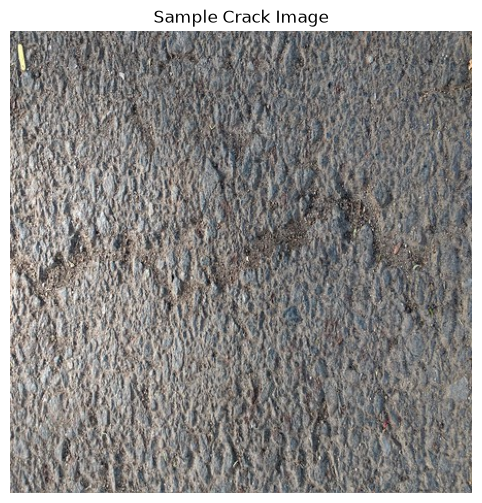

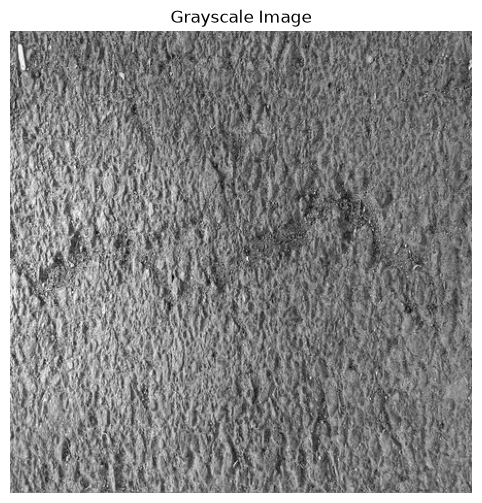

In [7]:
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(image_one, cv2.COLOR_BGR2RGB))
plt.title("Sample Crack Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(gray_one, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()


## 8. Visualize Canny Edge Detection

Canny edge detection highlights locations where there are strong changes in image intensity.

The resulting edge image is then used to calculate **edge density**, one of our numerical features.


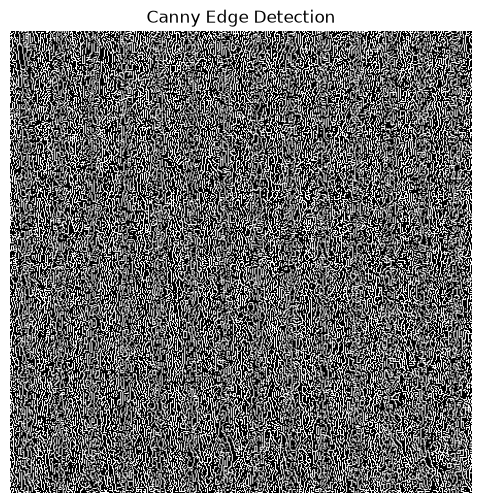

Sample edge density: 0.3773616868622449


In [8]:
edges_one = cv2.Canny(gray_one, 50, 100)

plt.figure(figsize=(6, 6))
plt.imshow(edges_one, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

print("Sample edge density:", np.mean(edges_one > 0))


## 9. Prepare Features and Labels for Machine Learning

The model receives only the five numerical image features.

`image_name` is not used as a feature because it identifies the file rather than describing its visual content.


In [9]:
feature_columns = [
    "mean_brightness",
    "contrast",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_density",
]

X = df[feature_columns]
y = df["label"]

print("Features shape:", X.shape)
print("Labels shape:", y.shape)


Features shape: (400, 5)
Labels shape: (400,)


## 10. Train-Test Split

The dataset is divided into:

- **80% training data** — used to learn the classification patterns
- **20% test data** — used to evaluate the trained models on unseen samples

`stratify=y` preserves the class proportions in both subsets, while `random_state=42` makes the split reproducible.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 320
Testing samples: 80


## 11. Model 1 — Logistic Regression

Logistic Regression is used as a baseline classifier. It learns a linear decision boundary between the two classes using the extracted numerical features.

Training time and prediction time are measured separately.


In [11]:
logistic_model = LogisticRegression(max_iter=1000)

# Training time
start_time = time.time()
logistic_model.fit(X_train, y_train)
logistic_training_time = time.time() - start_time

# Prediction time
start_time = time.time()
logistic_pred = logistic_model.predict(X_test)
logistic_prediction_time = time.time() - start_time

# Evaluation metrics
logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_precision = precision_score(y_test, logistic_pred)
logistic_recall = recall_score(y_test, logistic_pred)
logistic_f1 = f1_score(y_test, logistic_pred)

print(f"Accuracy        : {logistic_accuracy:.4f}")
print(f"Precision       : {logistic_precision:.4f}")
print(f"Recall          : {logistic_recall:.4f}")
print(f"F1-score        : {logistic_f1:.4f}")
print(f"Training time   : {logistic_training_time:.4f} seconds")
print(f"Prediction time : {logistic_prediction_time:.4f} seconds")


Accuracy        : 0.6625
Precision       : 0.6757
Recall          : 0.6250
F1-score        : 0.6494
Training time   : 0.0572 seconds
Prediction time : 0.0026 seconds


### Logistic Regression Confusion Matrix


[[28 12]
 [15 25]]


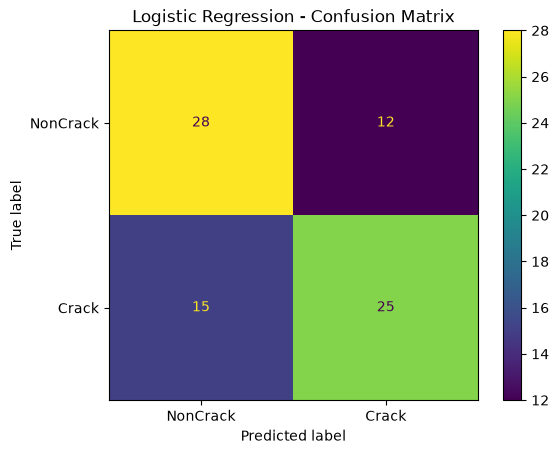

In [12]:
logistic_cm = confusion_matrix(y_test, logistic_pred)

print(logistic_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=["NonCrack", "Crack"]
)
disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


## 12. Model 2 — Random Forest

Random Forest uses multiple decision trees and combines their predictions. This allows it to model more complex relationships between the extracted features and the class label.

The same training and test data are used so that the classifier comparison is consistent.


In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Training time
start_time = time.time()
rf_model.fit(X_train, y_train)
rf_training_time = time.time() - start_time

# Prediction time
start_time = time.time()
rf_pred = rf_model.predict(X_test)
rf_prediction_time = time.time() - start_time

# Evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"Accuracy        : {rf_accuracy:.4f}")
print(f"Precision       : {rf_precision:.4f}")
print(f"Recall          : {rf_recall:.4f}")
print(f"F1-score        : {rf_f1:.4f}")
print(f"Training time   : {rf_training_time:.4f} seconds")
print(f"Prediction time : {rf_prediction_time:.4f} seconds")


Accuracy        : 0.9125
Precision       : 0.9231
Recall          : 0.9000
F1-score        : 0.9114
Training time   : 0.2850 seconds
Prediction time : 0.0212 seconds


### Random Forest Confusion Matrix


[[37  3]
 [ 4 36]]


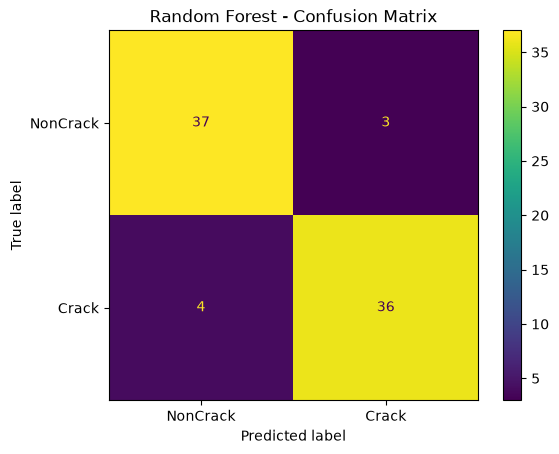

In [14]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["NonCrack", "Crack"]
)
disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()


## 13. Model 3 — Decision Tree

A Decision Tree classifies samples using a sequence of feature-based rules. Unlike Logistic Regression, it can model nonlinear relationships between the image features and the class label.


In [15]:
dt_model = DecisionTreeClassifier(random_state=42)

# Training time
start_time = time.time()
dt_model.fit(X_train, y_train)
dt_training_time = time.time() - start_time

# Prediction time
start_time = time.time()
dt_pred = dt_model.predict(X_test)
dt_prediction_time = time.time() - start_time

# Evaluation metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print(f"Accuracy        : {dt_accuracy:.4f}")
print(f"Precision       : {dt_precision:.4f}")
print(f"Recall          : {dt_recall:.4f}")
print(f"F1-score        : {dt_f1:.4f}")
print(f"Training time   : {dt_training_time:.4f} seconds")
print(f"Prediction time : {dt_prediction_time:.4f} seconds")


Accuracy        : 0.8500
Precision       : 0.8889
Recall          : 0.8000
F1-score        : 0.8421
Training time   : 0.0055 seconds
Prediction time : 0.0025 seconds


### Decision Tree Confusion Matrix


[[36  4]
 [ 8 32]]


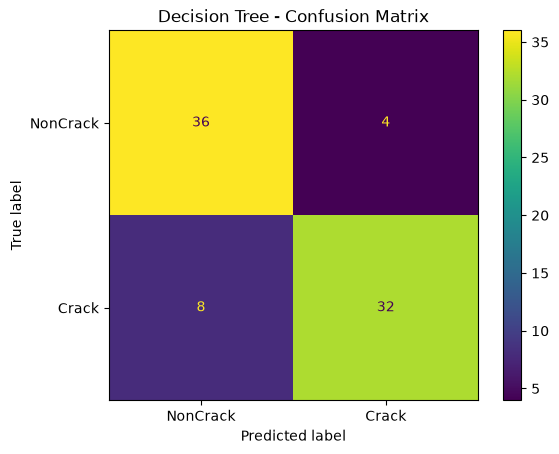

In [16]:
dt_cm = confusion_matrix(y_test, dt_pred)

print(dt_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=["NonCrack", "Crack"]
)
disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()


## 14. Compare All Models

The three models use the **same image representation, same train/test split, and same evaluation metrics**. Only the classification algorithm changes.

This allows us to compare how the choice of traditional classifier affects predictive performance and computation time.


In [17]:
results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1-Score": logistic_f1,
        "Training Time (s)": logistic_training_time,
        "Prediction Time (s)": logistic_prediction_time,
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1-Score": rf_f1,
        "Training Time (s)": rf_training_time,
        "Prediction Time (s)": rf_prediction_time,
    },
    {
        "Model": "Decision Tree",
        "Accuracy": dt_accuracy,
        "Precision": dt_precision,
        "Recall": dt_recall,
        "F1-Score": dt_f1,
        "Training Time (s)": dt_training_time,
        "Prediction Time (s)": dt_prediction_time,
    },
]

results_df = pd.DataFrame(results)

display(results_df)


,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.6625,0.675676,0.625,0.649351,0.057212,0.002616
1,Random Forest,0.9125,0.923077,0.900,0.911392,0.285012,0.021161
2,Decision Tree,0.8500,0.888889,0.800,0.842105,0.005483,0.002539


## 15. Observations

The observations below should be interpreted from the results produced by the notebook rather than from the model names alone.

1. **Logistic Regression** provides a linear baseline. If its metrics are lower than those of the tree-based models, this indicates that the current five-feature representation may contain nonlinear relationships that a linear decision boundary does not capture as effectively.

2. **Random Forest** combines multiple decision trees and can model more complex feature relationships. Its performance and computational cost should be examined directly in the comparison table.

3. **Decision Tree** also captures nonlinear relationships, but it uses a single tree rather than an ensemble of trees. Its metrics and timing can therefore be compared directly with both Logistic Regression and Random Forest.

4. The extracted representation is intentionally compact: each image is represented using only five global numerical features. This reduces the dimensionality considerably, but it also means that detailed spatial information about where a crack occurs in the image is not explicitly represented.

5. The model comparison is therefore a comparison of both **classifier behavior and the chosen feature representation**. A later representation change can be used to investigate whether different image features improve classification performance or computational efficiency.


## 16. Summary of Part A

The completed pipeline is:

```text
Asphalt Images
      ↓
Grayscale Conversion
      ↓
Feature Extraction
      ↓
Mean Brightness
Contrast
Dark-Pixel Ratio
Bright-Pixel Ratio
Canny Edge Density
      ↓
Feature DataFrame
      ↓
80/20 Stratified Train-Test Split
      ↓
Logistic Regression
Random Forest
Decision Tree
      ↓
Accuracy / Precision / Recall / F1
Confusion Matrices
Training Time / Prediction Time
```

The extracted feature table is also saved as:

```text
cracks_data.csv
```

### Important implementation notes

- Images are kept at their original dimensions; no resizing is performed in this notebook.
- Image features are derived directly from grayscale pixel intensities using NumPy/OpenCV.
- No CNN, deep-learning model, or pretrained image embedding is used.
- The test set is kept separate from model training.
- The same feature representation and split are used for all three classifiers.
